# Inferring Cell–Cell Interactions at Single Cell Resolution

## Background

In this tutorial, we:

- 1. introduce and demonstrate how to compute **inflow score**, a statistical approach that considers the source (sender) cell type of local ligand-receptor interactions, making it a suitable method for single-cell resolution technologies.
<br>

Specifically, inflow score quantifies how much a given cell is *influenced* by neighboring ligand-producing cells through **spatial weighting** of ligand and receptor expression.  
This formulation captures both the **directionality** and **locality** of intercellular signaling, offering a fine-grained view of communication “flows” within spatial transcriptomics data.

<br>

$$
\text{Inflow}_{i,s,\ell,r} =
\left(
\frac{
\sum_{j=1}^{n} W_{ij}\,L_{j,\ell}\,C_{j,s}
}{
\sum_{j=1}^{n} W_{ij}
}
\right)
R_{i,r}
$$

where:

- $W_{ij}$ — spatial connectivity weight between target cell *i* and neighboring cell *j*.
- $L_{j,\ell}$ — expression of ligand $\ell$ in cell *j*.
- $C_{j,s}$ — hard filter, 1 if cell *j* belongs to cell type *s*, otherwise 0. 
- $R_{i,r}$ — expression of receptor *r* in target cell *i*.
- $n$ — total number of cells.

In other words, Inflow score measures how strongly a cell is **receiving** ligand signals from its spatial neighborhood, accounting for both spatial proximity and cell-type context.


- 2. Showcase an approach to extend each of LIANA's single-cell CCC methods (see this [tutorial](https://liana-py.readthedocs.io/en/latest/notebooks/basic_usage.html)) to consider the minimum distances between cells from different cell types when computing cell–cell interactions.

---

## Load Packages

```pip install squidpy``` # Needed for SVGs

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9

import squidpy as sq

# embed inline figures as JPEG (not the 2x 'retina' PNG default) to keep the notebook small
sc.set_figure_params(ipython_format='jpeg')


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_

## Load and Prep Data

To demonstrate the inflow score in practice, we will apply it to a spatial transcriptomics dataset from [*A molecularly defined and spatially resolved cell atlas of the whole mouse brain*(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000 genes** across roughly 10 million cells in the adult **mouse brain**.

In [2]:
adata = li.ds.yao_2023()

In [3]:
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
adata.var_names = adata.var["gene_name"]

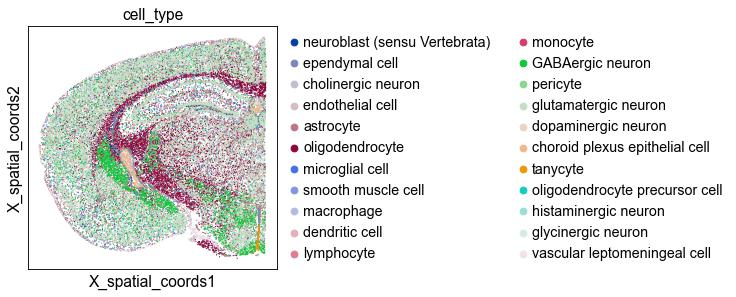

In [4]:
sc.pl.embedding(adata, basis="X_spatial_coords", color=["cell_type"], wspace=0.4, s= 5)

## Basic Prep and QC

In [5]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3) 

In [6]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

### Calculate spatial connectivity matrix Wij

Before calculating the inflow score, we first need to define the **spatial connectivity matrix** $W_{ij}$, which encodes how strongly each cell $i$ is connected to its spatial neighbors $j$.
In essence, $W_{ij}$ determines the *neighborhood* over which ligand signals are integrated, it specifies *who can talk to whom* in the tissue space.


#### Choosing the right bandwith

To compute $W_{ij}$, we typically use a **spatial kernel** (e.g., Gaussian) with a parameter called the **bandwidth** ($\sigma$), which controls the spatial scale of interactions:

- A **small bandwidth** captures only very **local** interactions (e.g., direct cell–cell contacts).  
- A **large bandwidth** allows **broader** neighborhoods, integrating ligand signals from more distant cells.  

Choosing the right bandwidth is therefore crucial:  
- **Biologically**, it should reflect the *typical range of molecular signaling* in the tissue.  
  For example, some ligands act only on adjacent cells (juxtacrine or short-range paracrine), while others diffuse more broadly through the extracellular space.  
- **Technically**, the optimal bandwidth also depends on the **spatial resolution**. <br>
    Because inflow score works at **single-cell resolution**, using too wide a bandwidth could blur fine spatial patterns, whereas too narrow a bandwidth might miss biologically relevant signaling gradients.  

In this step, you can explore different bandwidth values and examine how many neighbors each cell would have at each scale using  
`li.pp.query_bandwidth()`. This helps visualize the trade-off between **spatial resolution** and **neighborhood size**.

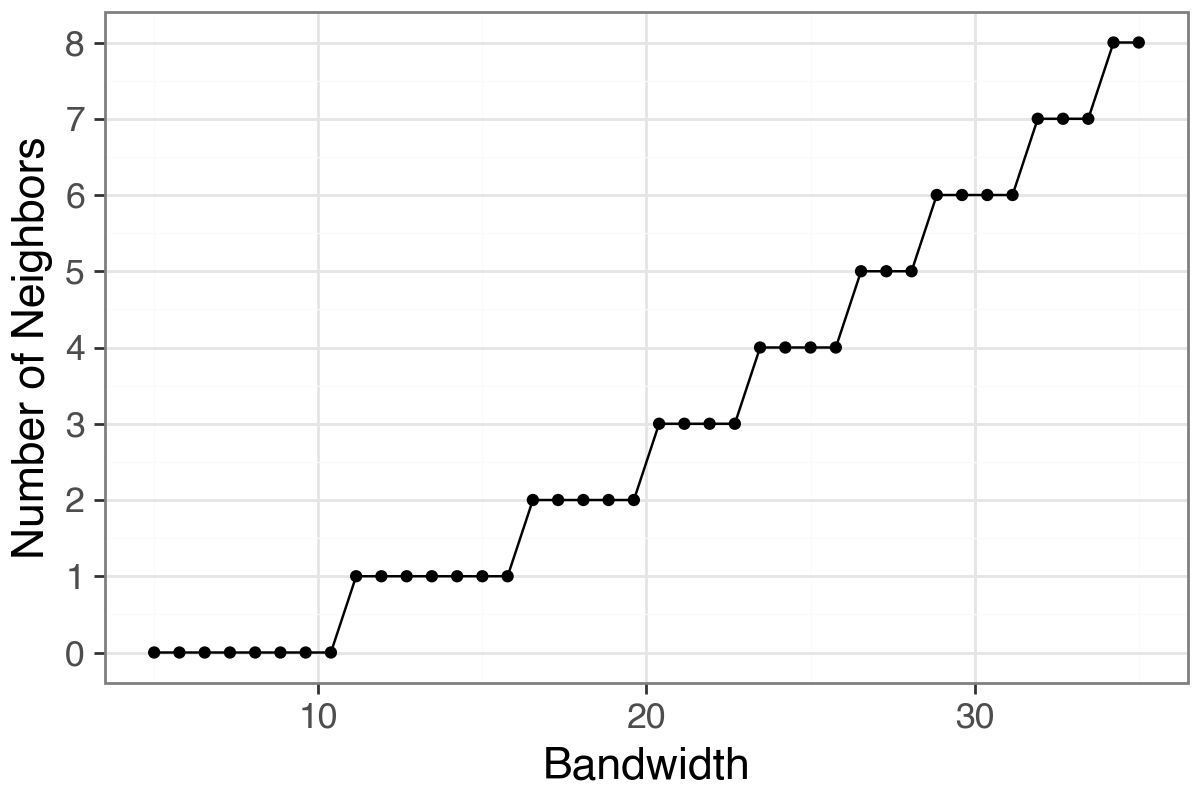

In [7]:
plot, df = li.pp.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,         
    end=35,           
    interval_n=40    
)
plot + p9.scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

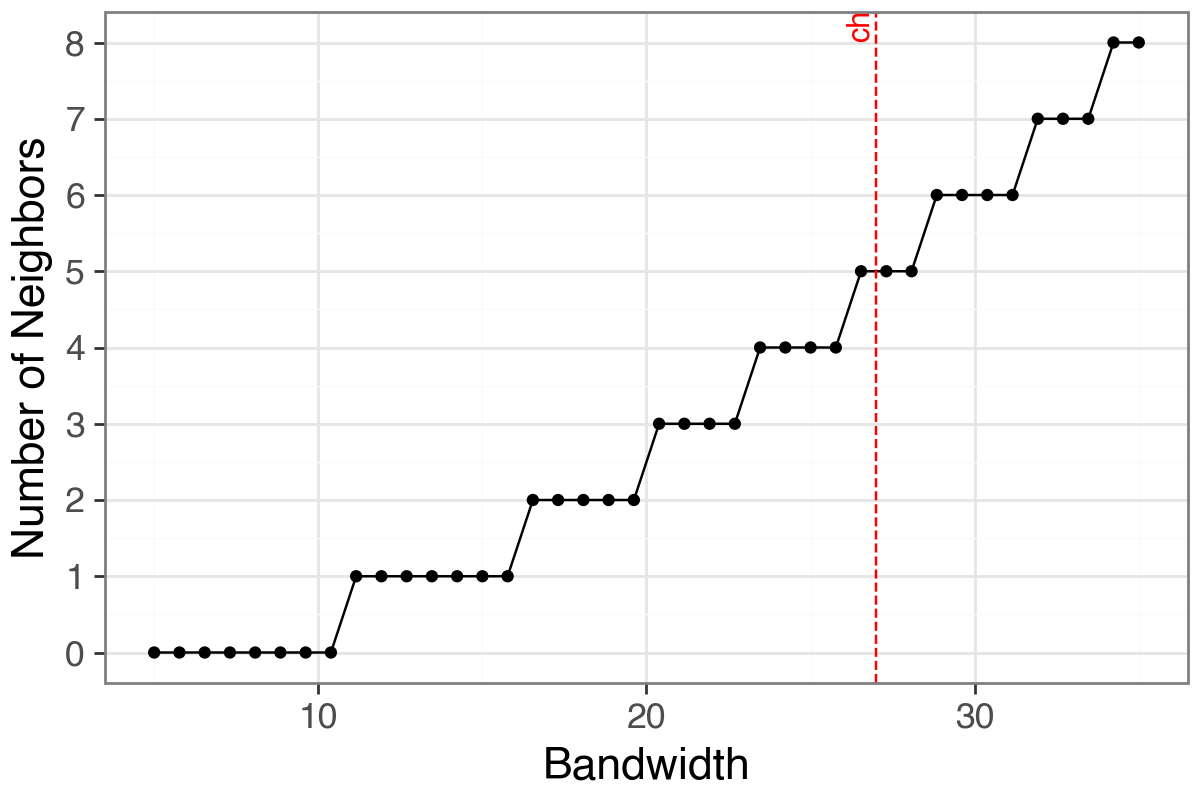

In [8]:
bandwidth = 27
plot + p9.geom_vline(xintercept=bandwidth, linetype="dashed", color="red") + \
       p9.annotate("text", x=bandwidth, y=df.neighbours.max(),
                label=f"chosen={bandwidth}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       p9.scale_y_continuous(breaks=range(int(df.neighbours.min()),
                                       int(df.neighbours.max())+1))

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [9]:
li.pp.spatial_neighbors(adata=adata, bandwidth=bandwidth, spatial_key="X_spatial_coords")

#### Visualize proximity

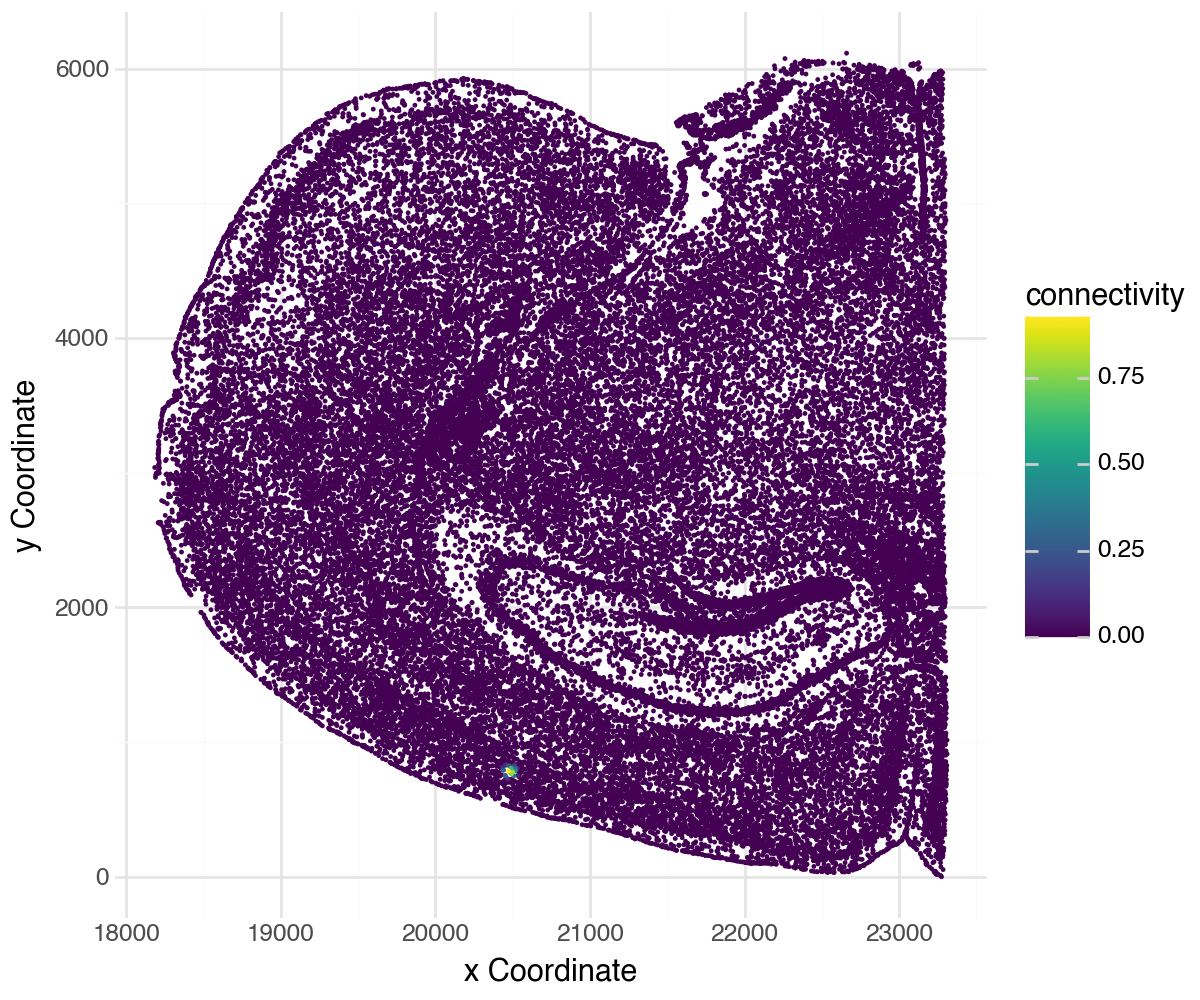

In [10]:
li.pl.connectivity(adata, idx=5500, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

### Find spatially variable genes (SVGs) using Morans'I

In [11]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [12]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
Slc17a7,0.540788,0.000000,0.000003,0.000000
Neurod2,0.521239,0.000000,0.000003,0.000000
Zic1,0.478535,0.000000,0.000003,0.000000
Clic6,0.471538,0.000000,0.000003,0.000000
Slc30a3,0.463036,0.000000,0.000003,0.000000
...,...,...,...,...
Gnrh1,0.000776,0.311201,0.000003,0.311757
Vsx2,0.000290,0.424026,0.000003,0.424405
Dmbx1,0.000250,0.433715,0.000003,0.433715
Pax8,-0.000854,0.302702,0.000003,0.303515


### Filter by spatially variable genes (SVGs)

In [13]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1027

In [14]:
adata = adata[:, svgs]

## Compute inflow score 

### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [15]:
resource = li.rs.select_resource('consensus') #NOTE: there is a mouse_consensus resource and we should recreate it once we update consensus :)
map_df = li.rs.get_hcop_orthologs(target_organism='mouse',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})
# We will then translate; 
resource = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=2
                                 )

/Users/b260-admin/Repos/liana-py/src/liana/resource/_orthology.py:281: DtypeWarning: Columns (0: human_entrez_gene) have mixed types. Specify dtype option on import or set low_memory=False.


In [16]:
lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource=resource,
                      # keep the pre-2.0 default; `Ntf3^Ntrk3` inflow is sparse and is masked at the new default of 0.05
                      nz_prop=0.001,
                      use_raw=False)
                                  
lrdata.shape

/Users/b260-admin/Repos/liana-py/src/liana/method/sp/_inflow.py:325: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(51539, 1738)

### Optional: filter data to keep only spatially variable LR interaction

In [17]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [18]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1396

In [19]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
neuroblast (sensu Vertebrata)^Efna5^Epha4,0.496809,0.0,0.000003,0.0
smooth muscle cell^Sostdc1^Lrp4,0.499898,0.0,0.000003,0.0
tanycyte^Spp1^S1pr1,0.506309,0.0,0.000003,0.0
neuroblast (sensu Vertebrata)^Wnt5a^Epha7,0.509199,0.0,0.000003,0.0
glutamatergic neuron^Gnb3^Gabbr2,0.520579,0.0,0.000003,0.0
tanycyte^Efna5^Ephb1,0.579937,0.0,0.000003,0.0
glutamatergic neuron^Efna5^Epha4,0.590864,0.0,0.000003,0.0
neuroblast (sensu Vertebrata)^Ntf3^Ntrk3,0.642659,0.0,0.000003,0.0
tanycyte^Wnt5a^Fzd5,0.766413,0.0,0.000003,0.0
glutamatergic neuron^Ntf3^Ntrk3,0.807822,0.0,0.000003,0.0


### Visualizations

1. **Spatial inflow intensity for a single ligand–receptor interaction.** <br>
Here, we focus on a single interaction to illustrate the spatial distribution of inferred signaling. <br>
Specifically, we show signal sourced from **glutamatergic neurons** via the ligand **Ntf3** and received through the receptor **Ntrk3**. The inflow intensity reflects the strength of inferred ligand–receptor–mediated signaling at each spatial location.

In [20]:
#Define variables
cell_type_col = "cell_type"
brain_regions = "major_brain_region"
spatial_key = "X_spatial_coords"

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


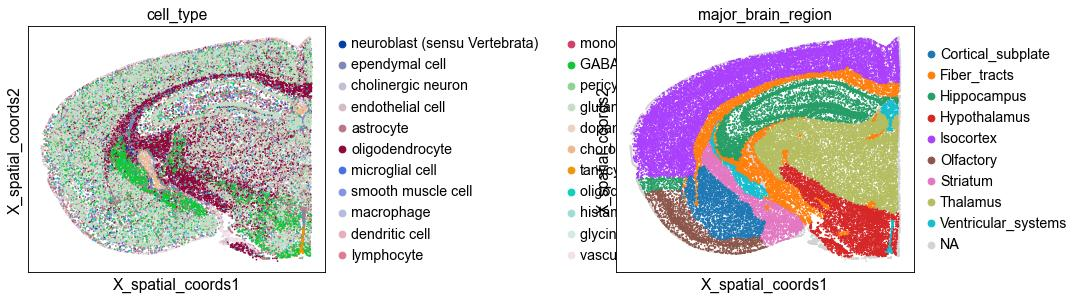

In [21]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=[cell_type_col, brain_regions],
    s=10,
    ncols=2,
    cmap="RdBu_r",
    wspace=0.8
)

In [22]:
interaction = 'glutamatergic neuron^Ntf3^Ntrk3'
comp = interaction.split("^")

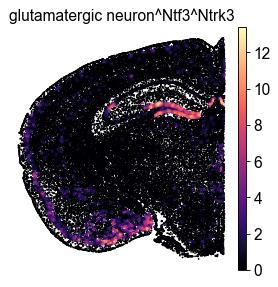

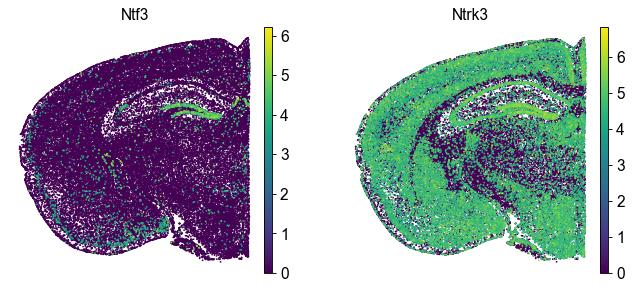

In [23]:

sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=interaction,
    s=10,
    ncols=2,
    cmap='magma',
    frameon=False
)

sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[comp[1], comp[2]],
    s=10,
    use_raw=False,
    ncols=2,
    frameon=False
)

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_83863/4116100833.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


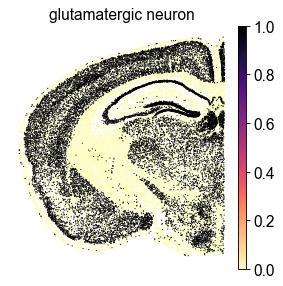

In [24]:
mask = adata.obs[cell_type_col] == 'glutamatergic neuron'
adata.obs['glutamatergic neuron'] = 0
adata.obs.loc[mask, 'glutamatergic neuron'] = 1
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color='glutamatergic neuron',
    s=4,
    use_raw=False,
    ncols=2,
    cmap='magma_r',
    frameon=False
)

2. **Rank cell types receiving inflow from glutamatergic neuron–Ntf3–Ntrk3 axis.** <br>
Here, we compare how different cell types receive signaling from **glutamatergic neuron–Ntf3–Ntrk3 axis**. Cell types with higher inflow values indicate stronger inferred reception of this signaling interaction. <br>
From this comparison, **neuroblasts, astrocytes, and GABAergic neurons** show the highest inflow values among other cell types.

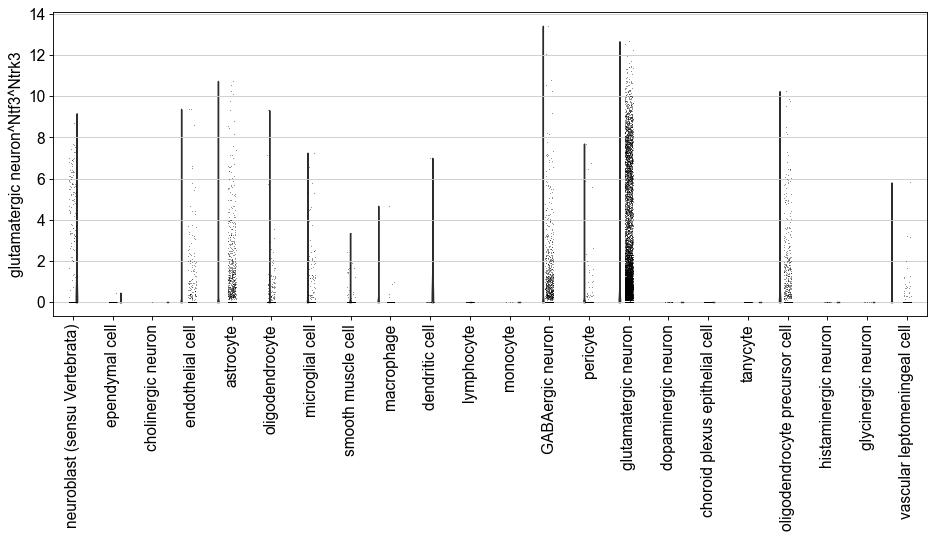

<Figure size 320x320 with 0 Axes>

In [25]:
fig, ax = plt.subplots(figsize=(14, 5)) 

sc.pl.violin(lrdata, groupby=cell_type_col, keys=interaction,size=0.5,rotation=90, ax=ax)

plt.tight_layout()
plt.show()

#### Single Interaction by Regions


3. **Spatial representatuion of cells receiving signaling from glutamatergic neuron–Ntf3–Ntrk3 axis.** <br>

In this plot, we visualize the spatial locations of cells receiving signaling from the glutamatergic neuron–Ntf3–Ntrk3 axis across the tissue section. Cells are colored by their cell type, and color intensity reflects the strength of the inferred inflow signal received through the Ntrk3 receptor. <br>

Here, we show that signaling from glutamatergic neurons via Ntf3 is predominantly received by neuroblasts (sensu Vertebrata) in the hippocampal region. In contrast, the same signaling axis is received by GABAergic neurons, astrocytes, and oligodendrocyte precursor cells in the olfactory and Straitum regions. <br>

The numbers shown below each color bar indicate the count of cells with a **nonzero inflow score** for the **glutamatergic neuron–Ntf3–Ntrk3** interaction.

(<Figure size 800x640 with 5 Axes>,
 <Axes: title={'center': 'glutamatergic neuron^Ntf3^Ntrk3'}>)

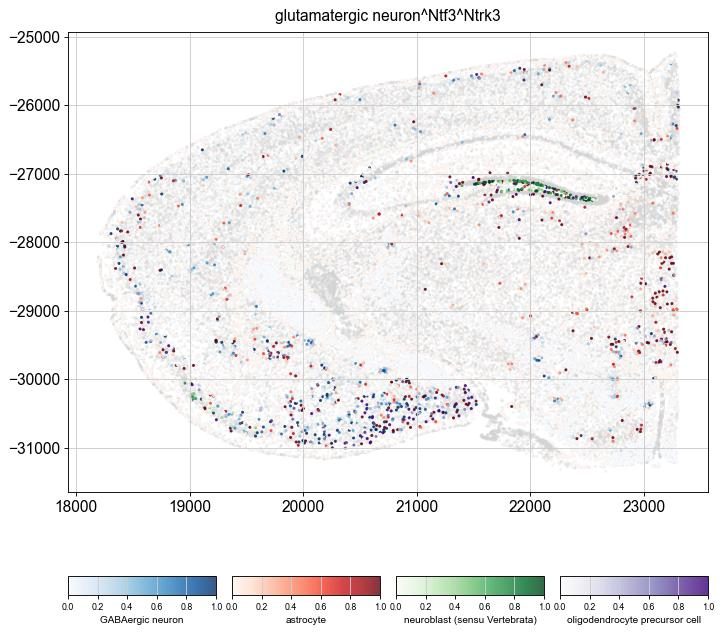

In [26]:
li.pl.feature_by_group(
    adata=lrdata,
    spatial_key=spatial_key,
    feature=interaction,
    groupby=cell_type_col,
    percentile_scaling = (1,97),
    labels=["GABAergic neuron", 'astrocyte', "neuroblast (sensu Vertebrata)", "oligodendrocyte precursor cell"],
    show_counts=False,
    normalize=True,
    figure_size=(10,8)
)

### Global Summaries

In addition to the high resolution inflow (single-cell level), we can summarize to get global scores and specificity for each interaction across (receiver) cell types:

In [27]:
li.mt.compute_global_specificity(lrdata, groupby='cell_type',
                                 n_perms=100, verbose=True, use_raw=False)

Running 100 permutations in parallel...


Running permutations:   0%|          | 0/100 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Running permutations:   8%|▊         | 8/100 [00:00<00:02, 44.01it/s]

Running permutations:  16%|█▌        | 16/100 [00:03<00:18,  4.43it/s]

...

Running permutations:  51%|█████     | 51/100 [00:03<00:02, 24.09it/s]

Running permutations:  72%|███████▏  | 72/100 [00:03<00:00, 43.93it/s]

[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    4.0s
Running permutations:  88%|████████▊ | 88/100 [00:04<00:00, 59.01it/s]

Running permutations: 100%|██████████| 100/100 [00:04<00:00, 24.46it/s]

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.3s finished


In [28]:
lrdata.uns['global_interactions'].sort_values("lr_mean", ascending=False).head(3)

,source,ligand_complex,receptor_complex,target,lr_mean,pval
566,choroid plexus epithelial cell,Col18a1,Gpc4,choroid plexus epithelial cell,3.796632,0.009901
105,tanycyte,Efna5,Ephb1,tanycyte,3.617474,0.009901
413,tanycyte,Rspo3,Lgr6,tanycyte,2.401177,0.009901


We can use global summary to find **the** cell type pairs which are specific to the **Ntf3->Ntrk3** axis:

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_83863/1471136160.py:15: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.


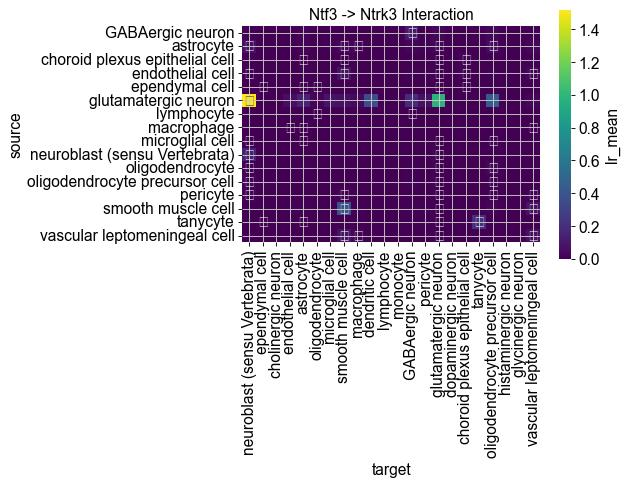

In [29]:
df = lrdata.uns['global_interactions']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lr_mean'),
    annot=interaction_df.pivot(index='source', columns='target', values='pval').map(lambda x: '★' if x < 0.05 else ''),
    fmt='',
    square=True,
    cmap='viridis',
    cbar_kws={'label': 'lr_mean'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

In addition, we can identify the top ligand–receptor pairs used by a specific source cell type. <br>
Here, we focus again on **glutamatergic neurons** as the signaling source and show the dominant ligand–receptor interactions they use to communicate with different target cell types. <br>

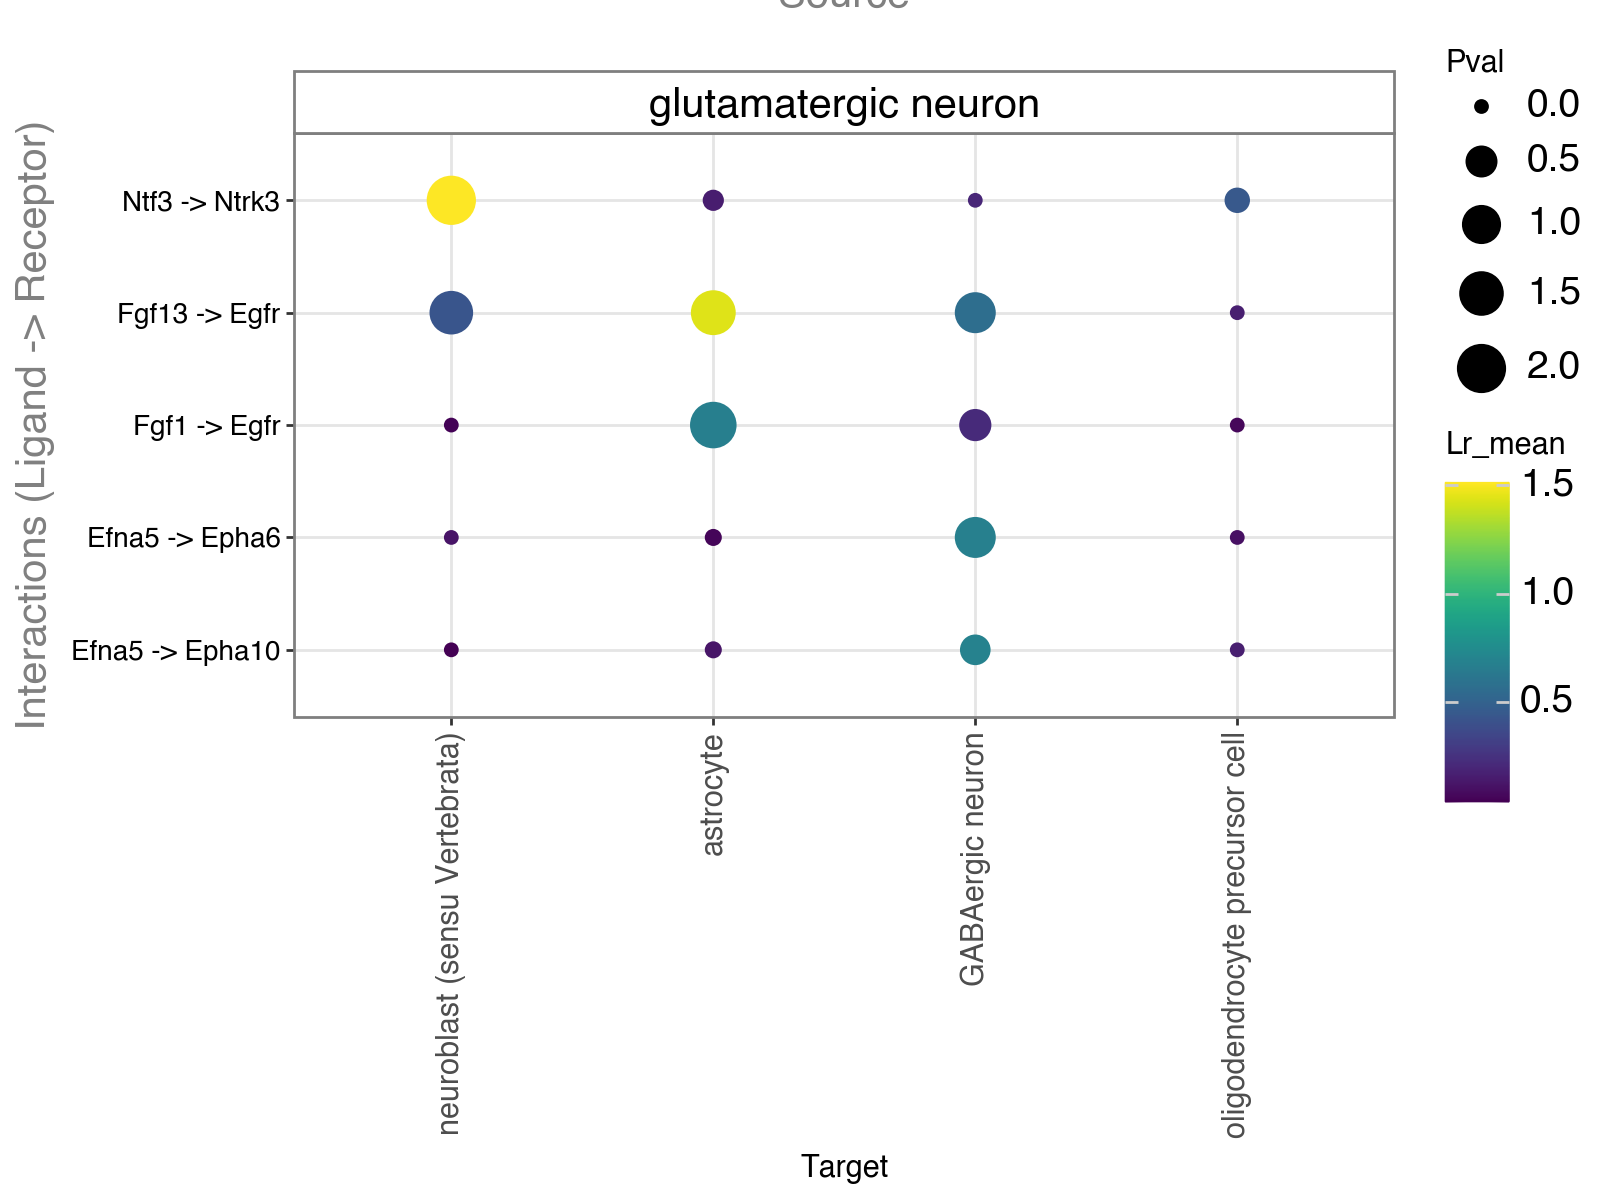

In [30]:
li.pl.dotplot(adata = lrdata, 
              colour="lr_mean",
              size ='pval',
              source_labels=["glutamatergic neuron"],
              target_labels=['neuroblast (sensu Vertebrata)', "astrocyte", "oligodendrocyte precursor cell", "GABAergic neuron"],
              filter_fn=lambda x: x['lr_mean'] > 0.5,
              inverse_size=True,
              figure_size=(8,6),
              uns_key='global_interactions' 
             )

Another use case of global summarization is to find region-specific differences by grouping interactions using spatial or niche-level metadata instead of cell types. <br>

Here, we group interactions by the *major_brain_region* annotation and recompute region-level specificity:

In [31]:
#ensure there is no Na
lrdata = lrdata[~lrdata.obs['major_brain_region'].isna()]

In [32]:
li.mt.compute_global_specificity(lrdata, groupby= "major_brain_region", uns_key='region_global_interactions',
                                 n_perms=100, verbose=True, use_raw=False)

Running 100 permutations in parallel...


Running permutations:   0%|          | 0/100 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Running permutations:  16%|█▌        | 16/100 [00:00<00:00, 99.85it/s]

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.2s
Running permutations:  32%|███▏      | 32/100 [00:00<00:00, 100.81it/s]

Running permutations:  48%|████▊     | 48/100 [00:00<00:00, 93.40it/s] 

...

Running permutations:  80%|████████  | 80/100 [00:00<00:00, 77.94it/s]

Running permutations:  96%|█████████▌| 96/100 [00:01<00:00, 76.37it/s]

Running permutations: 100%|██████████| 100/100 [00:01<00:00, 84.38it/s]

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.6s finished


/Users/b260-admin/Repos/liana-py/src/liana/method/sp/_compute_global_specificity.py:138: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


We then visualize the enrichment of the **Ntf3 → Ntrk3** interaction across brain regions. Using this approach, we observe that signaling from **glutamatergic neurons** through **Ntf3–Ntrk3** shows high specificity in regions such as the **hippocampus, striatum, and olfactory** regions, consistent with the spatial patterns observed earlier. <br>

This plot complements the previous analysis by summarizing interaction specificity at the region level, whereas earlier visualizations highlighted the cell types receiving the signal within those regions.

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_83863/3146697228.py:14: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.


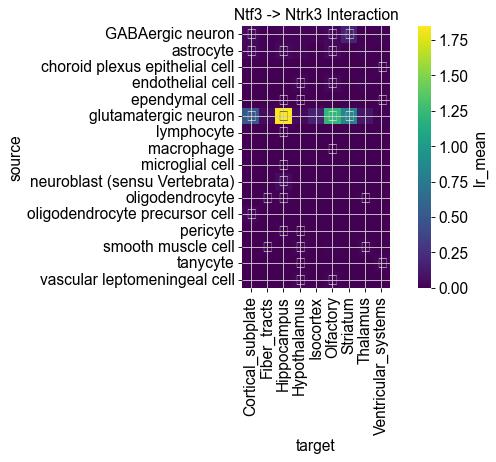

In [33]:
df = lrdata.uns['region_global_interactions']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lr_mean'),
    annot=interaction_df.pivot(index='source', columns='target', values='pval').map(lambda x: '★' if x < 0.05 else ('★★' if x < 0.01 else '')),
    fmt='',
    square=True,
    cmap='viridis',
    cbar_kws={'label': 'lr_mean'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

The final use case of global summary across regions and cell types, summarizing which cell types are sending and receiving signals, as well as where in the tissue these interactions are enriched. <br>

To do this, we construct a composite grouping variable by concatenating c*ell_type* and *major_brain_region*, and use this label to compute interaction specificity:

In [34]:
niche_label = "major_brain_region"
cell_type_col = "cell_type"
lrdata.obs["group_labels"] = lrdata.obs[cell_type_col].astype(str) + "::" + lrdata.obs[niche_label].astype(str)

In [35]:
li.mt.compute_global_specificity(lrdata, groupby= "group_labels",
                                 n_perms=1000, verbose=True, use_raw=False)

Running 1000 permutations in parallel...


Running permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Running permutations:   2%|▏         | 24/1000 [00:00<00:04, 236.17it/s]

[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s


...

Running permutations:  96%|█████████▌| 960/1000 [00:11<00:00, 94.67it/s]

Running permutations:  98%|█████████▊| 976/1000 [00:11<00:00, 91.04it/s]

Running permutations:  99%|█████████▉| 992/1000 [00:11<00:00, 94.12it/s]

Running permutations: 100%|██████████| 1000/1000 [00:11<00:00, 84.06it/s]

[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   12.1s finished


In [36]:
lrdata.uns["global_interactions"][["target", "niche"]] =lrdata.uns["global_interactions"]["target"].str.split("::", expand=True)
cols = [c for c in lrdata.uns["global_interactions"].columns if c not in ["lr_mean", "pval"]]
cols += ["lr_mean", "pval"]
lrdata.uns["global_interactions"] = lrdata.uns["global_interactions"][cols]
lrdata.uns["global_interactions"].sort_values("pval").head(3)

,source,ligand_complex,receptor_complex,target,niche,lr_mean,pval
119559,choroid plexus epithelial cell,Gnb3,Gabbr2,choroid plexus epithelial cell,Fiber_tracts,0.017657,0.000999
65239,astrocyte,Pdyn,Oprm1,glutamatergic neuron,Hypothalamus,0.060905,0.000999
61255,oligodendrocyte precursor cell,Adam12,Itga9,oligodendrocyte precursor cell,Hypothalamus,0.185208,0.000999


We then focus on the **Ntf3 → Ntrk3** interaction and retain interactions that are both statistically significant and show high interaction strength:

In [37]:
df = lrdata.uns['global_interactions']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')]
interaction_df = interaction_df[
    (interaction_df["pval"] < 0.05) &
    (interaction_df["lr_mean"] > 0.5)
]
interaction_df["interaction"] = interaction_df["source"] + "→" + interaction_df["target"]
interaction_df["reversed_pval_size"] = 1 / interaction_df["pval"] 
interaction_df["reversed_pval_size"] *= 0.5

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_83863/1921615817.py:43: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.


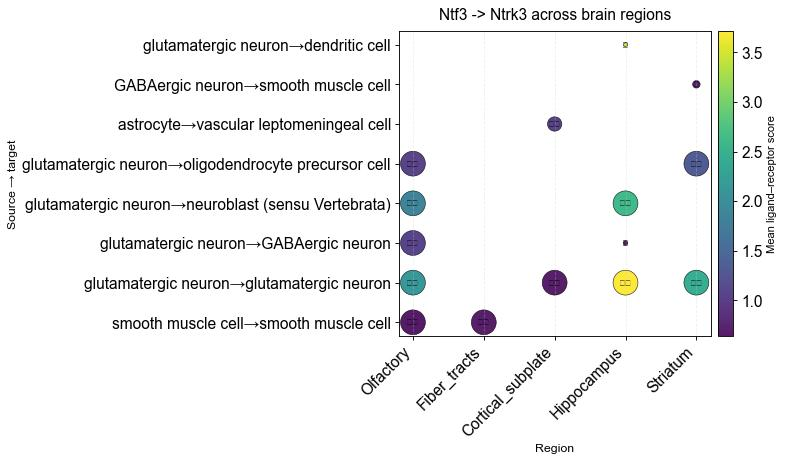

In [38]:
# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    interaction_df["niche"],
    interaction_df["interaction"],
    c=interaction_df["lr_mean"],
    s=interaction_df["reversed_pval_size"],  # Use reversed pval size
    cmap="viridis",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9
)

for i, row in interaction_df.iterrows():
    significance = '★★' if row["pval"] < 0.01 else ('★' if row["pval"] < 0.05 else '')
    if significance:
        ax.text(
            row["niche"],
            row["interaction"],
            significance,
            fontsize=8,
            ha='center',
            va='center',
            color='black'  # Adjust color for visibility
        )

# --- Labels & title ---
ax.set_title("Ntf3 -> Ntrk3 across brain regions", fontsize=14, pad=10)
ax.set_xlabel("Region", fontsize=11)
ax.set_ylabel("Source → target", fontsize=11)

# Rotate x labels
plt.xticks(rotation=45, ha="right")

# --- Colorbar ---
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Mean ligand–receptor score", fontsize=10)

# --- Grid & layout ---
ax.grid(True, axis="x", linestyle="--", alpha=0.3)
ax.grid(False, axis="y")
plt.tight_layout()

plt.show()

----

## Cell types spatial proximity
This method finds pairwise proximity between cell types using minimum nearest-neighbor distances in spatial coordinates (inspired by [CellChatv2](https://www.nature.com/articles/s41596-024-01045-4)) and compute proximity score using a kernel function (e.g., Gaussian). <br>
Proximity scores are used for weighting ligand–receptor interactions by how strongly the corresponding cell types co-localize across the whole slide.

Specifically, for each cell type pair $(A, B)$:

1. **Distance calculation**: Find nearest neighbor (euclidean) distances $d_i$ for each cell $i \in A$ to cells in $B$
   - For self-interactions $(A = A)$, exclude the cell itself (use 2nd nearest neighbor)

2. **Aggregation**: Compute trimmed mean distance 
   $$\bar{d}_{A,B} = \text{trim\_mean}(\{d_i\}, \alpha)$$
   where $\alpha$ is the trim fraction (default: 0.1)

3. **Proximity score**: Apply kernel function (e.g. Gaussian $K(d, \sigma) = \exp\left(-\frac{d^2}{2\sigma^2}\right)$) to mean distance, where $\sigma$ is the bandwidth parameter controlling the spatial scale of proximity.
   $$p_{A,B} = K(\bar{d}_{A,B}, \sigma)$$

4. **Multiply** each ligand–receptor interaction score between cell types $A$ and $B$ by proximity score $p_{A,B}$ to get proximity-weighted interaction scores.

### Calculate Cell Pair Proximity on their own:

In [39]:
pair_proximity = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian', bandwidth=100, spatial_key='X_spatial_coords', verbose=True)

Computing cell type proximities:   0%|          | 0/484 [00:00<?, ?it/s]

Computing cell type proximities:   1%|          | 3/484 [00:00<00:25, 18.74it/s]

Computing cell type proximities:   2%|▏         | 10/484 [00:00<00:11, 41.19it/s]

Computing cell type proximities:   4%|▎         | 18/484 [00:00<00:08, 54.22it/s]

Computing cell type proximities:   5%|▌         | 26/484 [00:00<00:07, 62.12it/s]

...

Computing cell type proximities:  94%|█████████▎| 453/484 [00:06<00:00, 73.30it/s]

Computing cell type proximities:  95%|█████████▌| 461/484 [00:06<00:00, 75.17it/s]

Computing cell type proximities:  97%|█████████▋| 469/484 [00:06<00:00, 74.85it/s]

Computing cell type proximities:  99%|█████████▊| 477/484 [00:06<00:00, 74.92it/s]

Computing cell type proximities: 100%|██████████| 484/484 [00:06<00:00, 72.49it/s]

**interacting** is a binary flag where the value is **0** if an sufficient proximity of cells are co-localized across two cell types for them to be considered as interacting, and 1 otherwise. <br> While **proximity** is a spatial co-localization weight between two cell types, bound between 0 and 1 (based on the `bandwidth`). Higher values means closer proximity and stronger interactions, while lower values reflect weaker or no spatial co-localization.

In [40]:
pair_proximity.sort_values('proximity', ascending=True).head(3)

,source,target,mean_distance,interacting,proximity
133,endothelial cell,cholinergic neuron,4022.129117,0,0.0
419,smooth muscle cell,cholinergic neuron,3877.382295,0,0.0
177,glutamatergic neuron,cholinergic neuron,4252.846167,0,0.0


<Axes: xlabel='target', ylabel='source'>

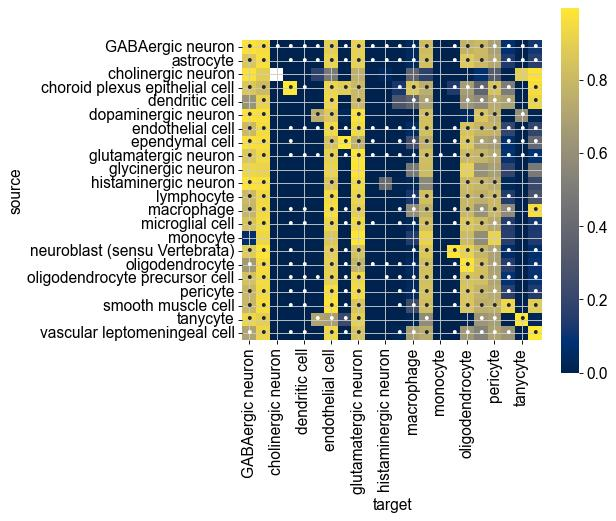

In [41]:
plt.figure(figsize=(6, 6))
proximity = 'proximity'
interacting = 'interacting'
sns.heatmap(
    data=pair_proximity.pivot(index='source', columns='target', values=proximity),
    annot=pair_proximity.pivot(index='source', columns='target', values=interacting).fillna(0).astype(int).replace({1: '•', 0: ''}),
    fmt='',
    cmap='cividis',
    square=True
)

The heatmap indicates that e.g. the **smooth muscle cell** and **tanycyte** pair did not meet the interaction criteria (interaction == 0). Based on the spatial plot below, despite the abundance of smooth muscle cells (n = 4314), tanycytes are highly localized, lacking sufficient proximity to smooth muscle cells to pass the filter.

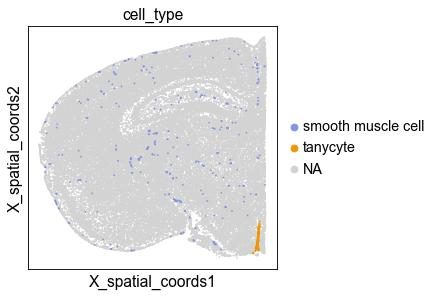

In [42]:
sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color="cell_type",
    groups=["smooth muscle cell", "tanycyte"],
    s=10,
)

### Weight LR inference by cell type pair spatial proximity (as described above)

Using `rank_aggregate`, we can identify ligand-receptor (LR) pairs and apply weights to them based on the `spatial proximity` of interacting cell pairs. For example:

In [43]:
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     spatial_key='X_spatial_coords',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     spatial_kwargs={'kernel':'gaussian', 'bandwidth':100},
                     )

Using resource `mouseconsensus`.


Using `.X`!


The following cell identities were excluded: cholinergic neuron, monocyte


0.84 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 51535 samples and 107 features


...

 50%|█████     | 500/1000 [00:00<00:00, 738.22it/s]

 75%|███████▌  | 750/1000 [00:01<00:00, 693.78it/s]

100%|██████████| 1000/1000 [00:01<00:00, 715.18it/s]

100%|██████████| 1000/1000 [00:01<00:00, 714.51it/s]

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [44]:
adata.uns["liana_res"].sort_values(['magnitude_rank', 'lrscore'], ascending=(True, False)).head(3)

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
5424,dopaminergic neuron,glutamatergic neuron,Efna5,Epha4,3.216962,0.0,10.531641,1.213030,1.966449,0.043205,0.848946,8.160297e-07,1.751662e-11
23780,vascular leptomeningeal cell,endothelial cell,Spp1,S1pr1,3.110099,0.0,9.670934,1.565816,2.773729,0.023733,0.815820,3.654996e-06,1.401329e-10
10699,histaminergic neuron,GABAergic neuron,Hdc,Hrh3,3.053615,0.0,7.956484,2.980445,3.313899,0.063879,0.829188,3.152352e-10,1.995252e-10


Visualize interactions from **glutamatergic neuron** to various target cell types, weighted by their spatial proximity. <br>

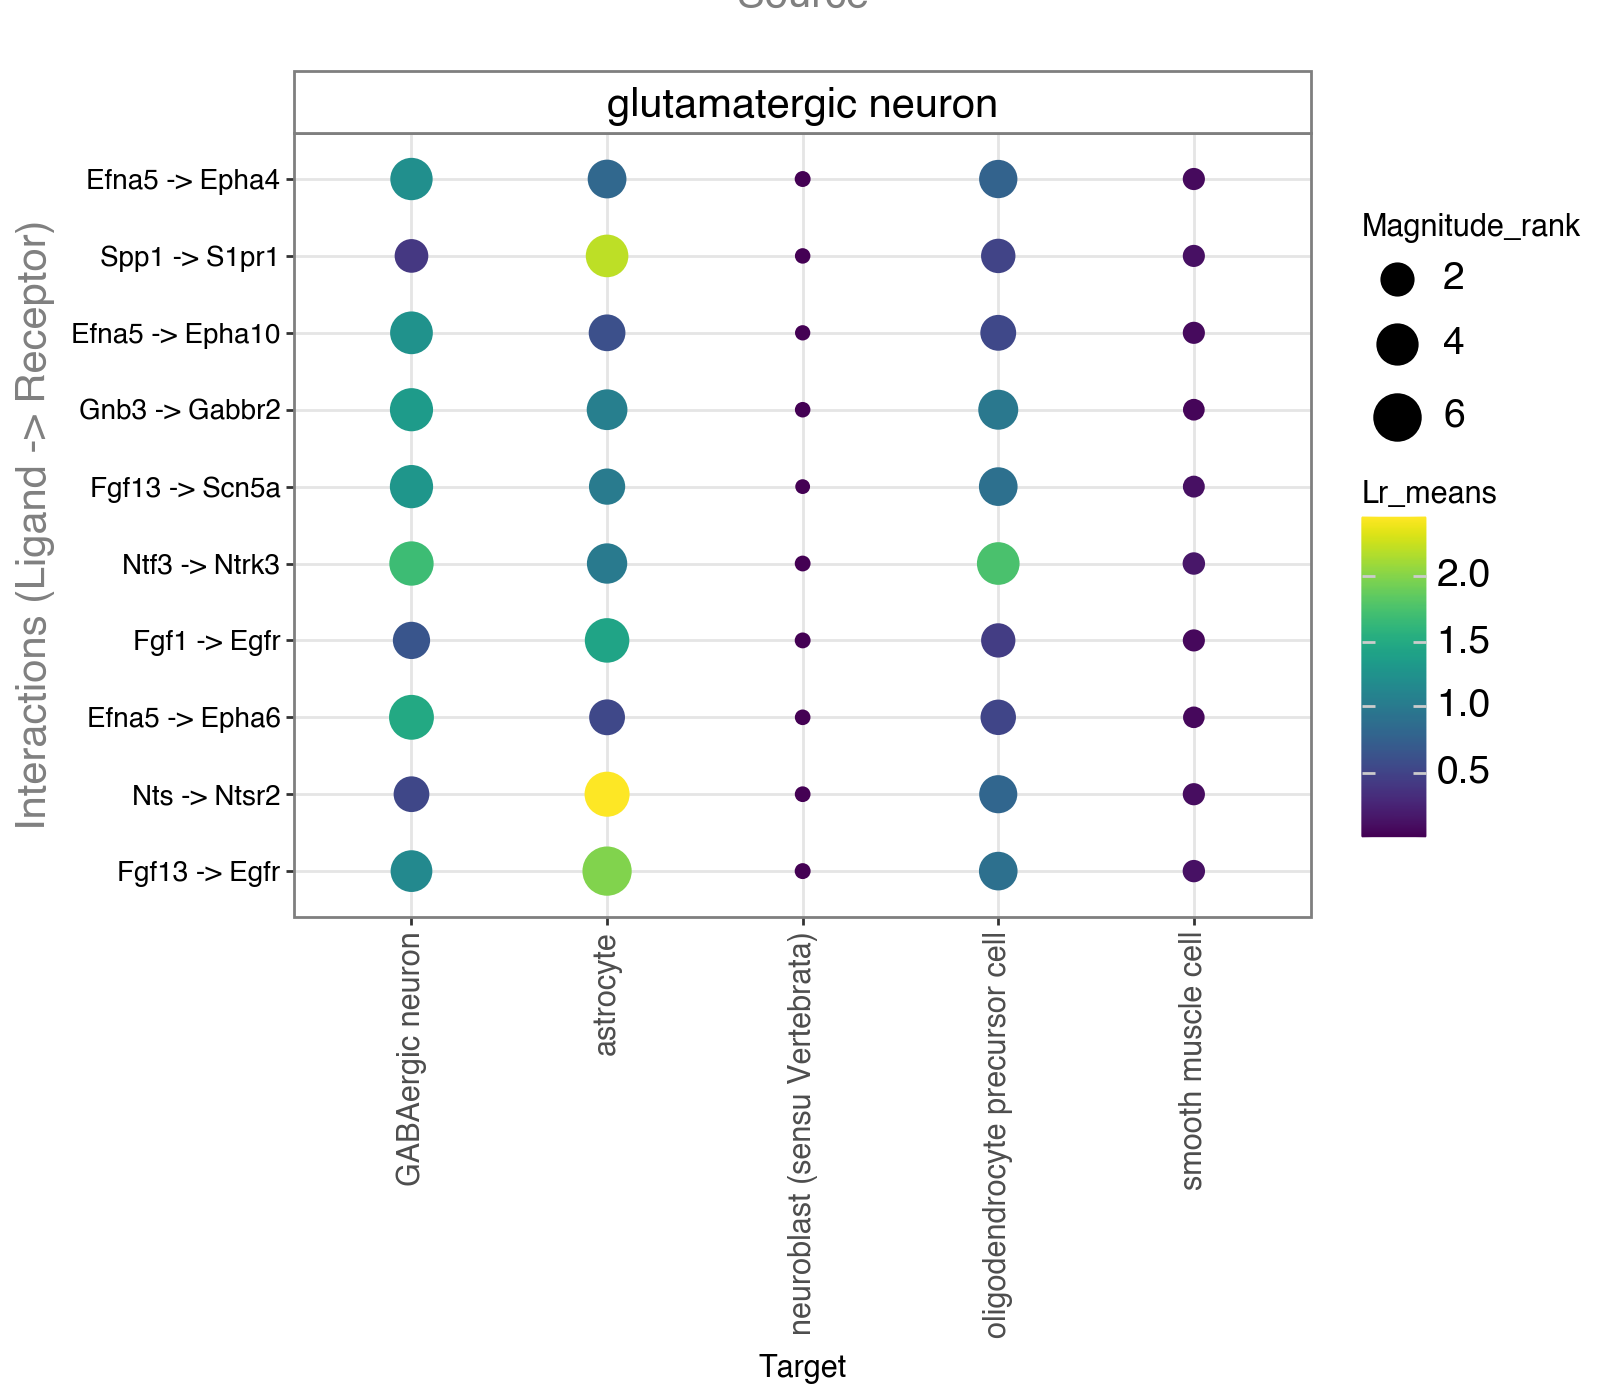

In [45]:
li.pl.dotplot(adata = adata, 
              colour='lr_means',
              size='magnitude_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=["glutamatergic neuron"],
              target_labels=['neuroblast (sensu Vertebrata)', "astrocyte", "oligodendrocyte precursor cell", "GABAergic neuron", "smooth muscle cell"],
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

Visualize a specific interaction fo interest:

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_83863/2399875420.py:14: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.


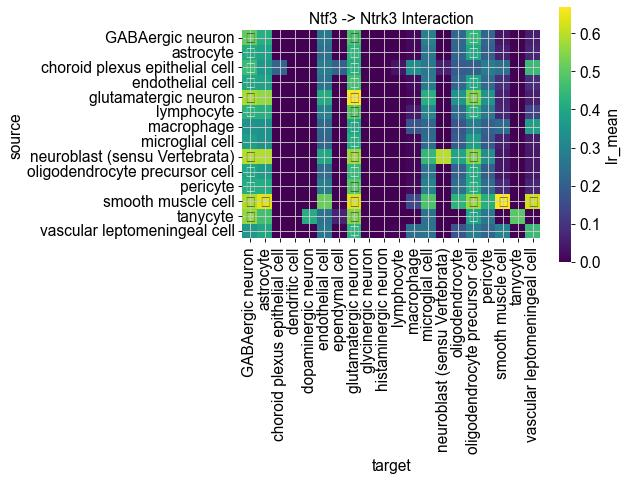

In [46]:
df = adata.uns['liana_res']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lrscore'),
    annot=interaction_df.pivot(index='source', columns='target', values='specificity_rank').map(lambda x: '★' if x < 0.05 else ('★★' if x < 0.01 else '')),
    fmt='',
    square=True,
    cmap='viridis',
    cbar_kws={'label': 'lr_mean'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>